In [1]:
import torch

import torch.nn as nn
import pandas as pd

In [2]:
data  = pd.read_csv("powerplant_data.csv")
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


## Input features

#### AT=> Temperature
#### V=> Vaccum
#### AP=> Pressure
#### RH=> Humidity

## Output Feature
#### PE => Power output

In [3]:
X = data.drop(columns="PE")
y = data["PE"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)

# 1. Scale the data

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_test_scaled

array([[ 1.34542332e+00,  2.36560963e-01, -1.27863796e+00,
        -1.10924515e+00],
       [ 8.11502793e-01,  1.36128832e+00, -7.35754700e-01,
         2.60147599e-01],
       [-2.42956790e-01, -7.41770813e-01,  1.99383535e+00,
        -2.01576508e-01],
       ...,
       [ 1.32267483e+00,  7.94595742e-01,  1.01543683e-03,
        -9.44588703e-01],
       [ 5.88032298e-01,  1.42346709e+00, -8.75690446e-01,
         9.38669354e-01],
       [-1.49680023e+00, -1.06604490e+00,  1.74599734e+00,
         5.31830728e-01]])

# 2. Convert the data into tensors

In [5]:
X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1,1)

# 3. Dataset and DataLoader Creation

In [6]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

train_dataset[0]

(tensor([-0.1921, -1.0322, -3.3895, -0.7703]), tensor([457.5300]))

In [7]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

# to see whats in train_loader
for X_batch, y_batch in train_loader:
    print(X_batch)
    print(y_batch)
    break

tensor([[ 1.0684,  1.3880, -1.3090,  0.6423],
        [-0.0074,  0.4349,  0.8541,  0.7761],
        [ 0.3552,  1.0158,  0.6940,  0.1600],
        [ 1.4418,  1.0504, -1.1775, -1.3260],
        [-0.3072, -0.9039,  0.2371,  0.0440],
        [ 0.2816,  0.4294,  0.5793, -0.0397],
        [ 1.5662,  1.0213,  0.0887, -2.3984],
        [-1.1301, -0.9700, -2.2295,  1.5897],
        [-1.5195, -1.4375,  1.2082,  0.5497],
        [ 1.2451,  0.9764,  0.8440, -0.8945],
        [ 0.2214, -0.4269, -0.3868, -0.5782],
        [-1.7845, -0.9661, -1.4506,  0.2896],
        [-0.8358, -0.9889, -0.5081, -0.6139],
        [-1.5758, -0.9047, -0.1743,  1.4196],
        [ 0.5412,  1.3873, -0.6059,  1.3386],
        [ 0.3311,  0.5057,  0.8086,  0.7102],
        [-1.5022, -1.3266, -0.6734,  0.5922],
        [ 1.8272,  2.0334, -0.3581, -0.6544],
        [ 0.6188,  1.0968, -1.3124, -0.4040],
        [ 1.2303,  1.6730,  0.8760, -1.3418],
        [ 1.6626,  1.3062, -1.0628, -1.6204],
        [-0.5387, -1.0590, -1.0460

# Deep Learning

In [8]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(

            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)

In [9]:
# Loss Functions and Optimizers

import torch.optim as optim

model = ANN()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [10]:
# Train the ANN

epochs = 100  # we want the model to go through 100 times from whole data
loss_train = []
validate_loss = []
best_model = float("inf")

for i in range(epochs):
    model.train()  # tells that model is now in training mode
    loss_per_epoch = 0.0

    for xb,yb in train_loader:
        # xb => features batch wise
        # yb => labels batch wise

        output = model(xb)  # predicts output
        loss = criterion(output,yb)  # calculate loss
        loss_per_epoch += loss.item()
        optimizer.zero_grad()  # clears prevouis gradients
        loss.backward()  # analyzing the loss now do backward propogation and update gradient
        optimizer.step() # optimize the loss by updating the params

    avg_train_loss = (loss_per_epoch)/len(train_loader)
    loss_train.append(avg_train_loss)


    model.eval()
    with torch.no_grad(): # No gradient compute
        loss_per_epoch = 0.0

        for xb,yb in test_loader:

            output = model(xb)
            loss = criterion(output,yb)
            loss_per_epoch += loss.item()


        avg_val_loss = loss_per_epoch/len(test_loader)
        validate_loss.append(avg_val_loss)

        if(avg_val_loss < best_model):
          # Save the model because Training takes too much time
          best_model = avg_val_loss
          torch.save(model.state_dict(),"best_ANN_Regressor_model.pt")

        print("Loss for Epoch",i+1," " ,avg_train_loss,"And", avg_val_loss)

Loss for Epoch 1   205795.9661111111 And 204050.61375
Loss for Epoch 2   196546.2109722222 And 184213.69770833335
Loss for Epoch 3   162378.37118055555 And 136338.6478125
Loss for Epoch 4   105617.04354166667 And 75469.51276041666
Loss for Epoch 5   53499.196640625 And 37213.97294270834
Loss for Epoch 6   28823.92202690972 And 22652.661901041665
Loss for Epoch 7   19316.574748263887 And 16392.472018229168
Loss for Epoch 8   14534.796762152779 And 12608.4763671875
Loss for Epoch 9   11187.922565104167 And 9624.264453125
Loss for Epoch 10   8422.130373263888 And 7119.9627473958335
Loss for Epoch 11   6123.829548611111 And 5113.15763671875
Loss for Epoch 12   4335.684083116319 And 3584.244073893229
Loss for Epoch 13   3009.965269097222 And 2480.8938623046874
Loss for Epoch 14   2071.1162090386283 And 1741.721905110677
Loss for Epoch 15   1459.4272454155816 And 1260.522157389323
Loss for Epoch 16   1065.7957187228733 And 941.923310546875
Loss for Epoch 17   786.8722800021701 And 710.322968

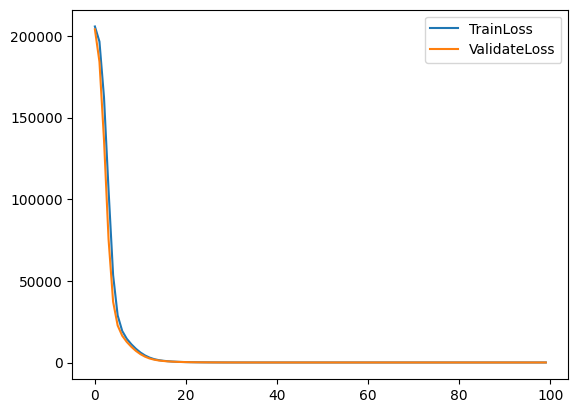

In [11]:
# lets Visualize the errors

import matplotlib.pyplot as plt

losses = pd.DataFrame({
    "train_loss":loss_train,
    "Validation_loss":validate_loss
})

plt.plot(losses["train_loss"],label="TrainLoss")
plt.plot(losses["Validation_loss"],label="ValidateLoss")

plt.legend()

In [12]:
# now to load and fit the model from file

model.load_state_dict(torch.load("best_ANN_model.pt"))

<All keys matched successfully>

In [13]:
# now Evaluate the model

model.eval()

train_loss = 0
test_loss =0

with torch.no_grad():

  train_pred = model(X_train_tensor)
  test_pred = model(X_test_tensor)

  train_loss = criterion(train_pred,y_train_tensor)
  test_loss = criterion(test_pred,y_test_tensor)


print("Train loss is: ",train_loss.item())
print("Test loss is: ",test_loss.item())

Train loss is:  21.088199615478516
Test loss is:  20.125085830688477


In [14]:
# calculate R^2 score

from sklearn.metrics import r2_score

print("R^2 score is: ",r2_score(test_pred,y_test_tensor))

R^2 score is:  0.9251833328141017


In [15]:
 predicted = pd.DataFrame(test_pred.numpy(),columns=["predicted"])
 actual = pd.DataFrame(y_test.values,columns=["actual"])


 df= pd.concat([predicted,actual],axis=1)

 df


,predicted,actual
0,435.333313,433.27
1,437.531555,438.16
2,461.492889,458.42
3,476.560089,480.82
4,435.735901,441.41
...,...,...
2387,453.497040,446.70
2388,429.840088,430.82
2389,434.490662,440.10
2390,439.138092,439.39


# compare the performance with other ML algos

In [16]:
# linear Regression

from sklearn.linear_model import LinearRegression

LR = LinearRegression()

LR.fit(X_train,y_train)

y_pred = LR.predict(X_test)
print("R^2 score is: ",r2_score(y_pred,y_test))


R^2 score is:  0.9247792673714147


In [17]:
# KNN

from sklearn.neighbors import KNeighborsRegressor

KNN = KNeighborsRegressor(n_neighbors=5)

KNN.fit(X_train_scaled,y_train)

y_pred = KNN.predict(X_test_scaled)

print("R^2 score is: ",r2_score(y_pred,y_test))


R^2 score is:  0.9499968977360231


## Conclusion

#### After training and evaluating multiple machine learning models on the dataset, their performance was compared using the R² score.

#### The results are as follows:

#### k-Nearest Neighbors (kNN) achieved an R² score of 0.9499
#### Linear Regression achieved an R² score of 0.9247
#### Artificial Neural Network (ANN) achieved an R² score of 0.951